### Preparing dataset



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls '/content/drive/MyDrive/Colab Notebooks/Deep_Learning/'

animals      DL_Experiment_01.ipynb	      placement-dataset.csv
archive.zip  Exp_1_Simple_Deep_Network.ipynb


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Deep_Learning/placement-dataset.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
# collapsing first column
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


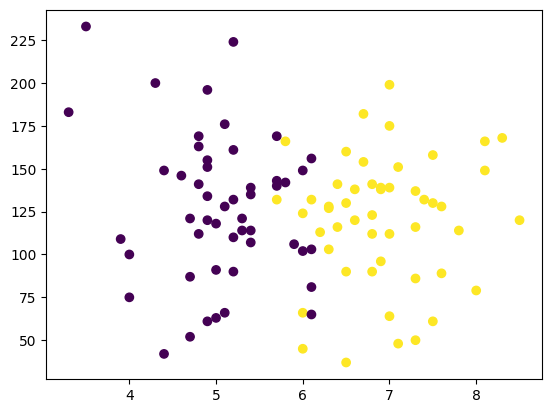

In [ ]:
plt.scatter(df['cgpa'], df['iq'], c = df['placement'])

In [ ]:
# seperating input and output columns
X = df.iloc[:,0:2].values
Y = df.iloc[:,-1].values

In [ ]:
X

array([[  6.8, 123. ],
       [  5.9, 106. ],
       [  5.3, 121. ],
       [  7.4, 132. ],
       [  5.8, 142. ],
       [  7.1,  48. ],
       [  5.7, 143. ],
       [  5. ,  63. ],
       [  6.1, 156. ],
       [  5.1,  66. ],
       [  6. ,  45. ],
       [  6.9, 138. ],
       [  5.4, 139. ],
       [  6.4, 116. ],
       [  6.1, 103. ],
       [  5.1, 176. ],
       [  5.2, 224. ],
       [  3.3, 183. ],
       [  4. , 100. ],
       [  5.2, 132. ],
       [  6.6, 120. ],
       [  7.1, 151. ],
       [  4.9, 120. ],
       [  4.7,  87. ],
       [  4.7, 121. ],
       [  5. ,  91. ],
       [  7. , 199. ],
       [  6. , 124. ],
       [  5.2,  90. ],
       [  7. , 112. ],
       [  7.6, 128. ],
       [  3.9, 109. ],
       [  7. , 139. ],
       [  6. , 149. ],
       [  4.8, 163. ],
       [  6.8,  90. ],
       [  5.7, 140. ],
       [  8.1, 149. ],
       [  6.5, 160. ],
       [  4.6, 146. ],
       [  4.9, 134. ],
       [  5.4, 114. ],
       [  7.6,  89. ],
       [  6

In [ ]:
Y

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1])

In [ ]:
X.shape

(100, 2)

In [ ]:
Y.shape

(100,)

###Initializing all weights zero with ReLU

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(2, activation = 'relu', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# default weights of model set by keras
model.get_weights()

[array([[ 0.45116222, -0.7362204 ],
        [ 0.55670846,  0.88890755]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.52656215],
        [-0.46673656]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
# changing weighs
initial_weights= model.get_weights()

In [ ]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [ ]:
model.set_weights(initial_weights)

In [ ]:
# updates weights and biases: all set to zero
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [ ]:
# training model
history = model.fit(X, Y, epochs= 100, validation_split= 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5547 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4844 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4961 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4922 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4805 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss

In [ ]:
# Observing updated weights
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([9.4420364e-05], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

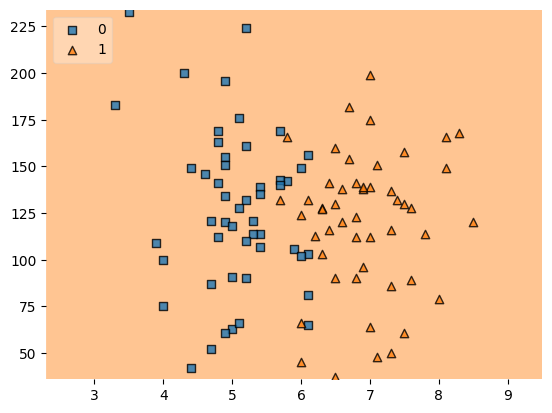

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X=X, y = Y.astype('int'), clf= model, legend = 2)

### Initializing all weights zero with Tanh

In [ ]:
model1 = Sequential()

model1.add(Dense(2, activation = 'tanh', input_dim = 2))
model1.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20 (84.00 B)

In [ ]:
# initial weights of model, which are randmly set by keras
model1.get_weights()

[array([[-0.5884534 , -0.6219008 ],
        [ 1.1185864 , -0.42618674]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.4074097],
        [ 1.2637857]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
# storing initial weights into variable
initial_weights1 = model1.get_weights()

In [ ]:
initial_weights1[0] = np.zeros(model1.get_weights()[0].shape)
initial_weights1[1] = np.zeros(model1.get_weights()[1].shape)
initial_weights1[2] = np.zeros(model1.get_weights()[2].shape)
initial_weights1[3] = np.zeros(model1.get_weights()[3].shape)

In [ ]:
# set updated weights to model
model1.set_weights(initial_weights1)

In [ ]:
# updates weights all zero's
model1.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
# compiling model
model1.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [ ]:
# training model
history1 = model1.fit(X, Y, epochs= 100, validation_split= 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4609 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5352 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4805 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5039 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5391 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss:

In [ ]:
# Updated weights
model1.get_weights()
# no training happened, because of all initial weights are zero

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.00254186], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

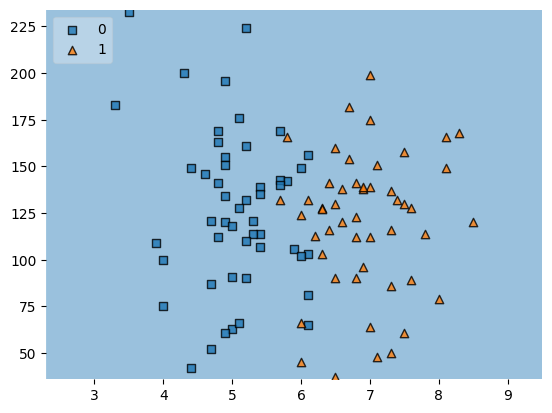

In [ ]:
# plotting decision boundary
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X = X, y = Y.astype('int'), clf= model1, legend=2)

### Initializing all weights to zero with sigmoid

In [ ]:
# when we initialize all weights to zero with hidden layer activation function as sigmoid
# all weights from one input feature will update with exactly same value
# If there are two input features and 2 hidden layers in hidden layer,
# then w11, w12 will have same updated value and w21, w22 will have same updated value in every epoch
# ie, anyway if there are 2 nodes in hidden layers it will act as single node, because wights coming are similiar.
# actually there are 4 weights coming from input layer, but due to all zero initialization, for updated weights, it looks like,
# only two weights are coming from input layer. ie, hidden layer act as having single neuron.
# In this case, if there are n nodes in hidden ayer, it will act is single node, if we initialize all weights to zero with sigmoid.
# it doesn't capture non-linearity, it acts as simple perceptron.


In [ ]:
# model2
model2 = Sequential()

model2.add(Dense(10, activation = 'sigmoid', input_dim = 2))
model2.add(Dense(1, activation = 'sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# initial weights
model2.get_weights()

[array([[ 0.6788755 ,  0.26409686, -0.08979893,  0.02136254, -0.41426608,
          0.17561072, -0.13940948, -0.01859719,  0.67307264,  0.11139429],
        [ 0.55863315,  0.0632599 ,  0.4737454 ,  0.44754237,  0.68031853,
         -0.3311692 , -0.04002434,  0.38693684, -0.3137718 ,  0.35561877]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.20760614],
        [-0.1825276 ],
        [-0.01095349],
        [-0.6213571 ],
        [-0.5318472 ],
        [-0.5910758 ],
        [ 0.43070716],
        [ 0.09241086],
        [ 0.35043246],
        [ 0.41373724]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
# storing initial weights
initial_weights2 = model2.get_weights()

In [ ]:
# updating weights
initial_weights2[0] = np.zeros(model2.get_weights()[0].shape)
initial_weights2[1] = np.zeros(model2.get_weights()[1].shape)
initial_weights2[2] = np.zeros(model2.get_weights()[2].shape)
initial_weights2[3] = np.zeros(model2.get_weights()[3].shape)

In [ ]:
# update weights
model2.set_weights(initial_weights2)

In [ ]:
# updated weighs
model2.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
# compiling model
model2.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [ ]:
# train model
history2 = model2.fit(X, Y, epochs=100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.4758 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4844 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4758 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4719 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4922 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4766 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4805 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss

In [ ]:
# trained weights
model2.get_weights()

[array([[ 0.3265236 ,  0.3265236 ,  0.3265236 ,  0.3265236 ,  0.3265236 ,
          0.3265236 ,  0.3265236 ,  0.3265236 ,  0.3265236 ,  0.3265236 ],
        [-0.02183719, -0.02183719, -0.02183719, -0.02183719, -0.02183719,
         -0.02183719, -0.02183719, -0.02183719, -0.02183719, -0.02183719]],
       dtype=float32),
 array([-0.0364312, -0.0364312, -0.0364312, -0.0364312, -0.0364312,
        -0.0364312, -0.0364312, -0.0364312, -0.0364312, -0.0364312],
       dtype=float32),
 array([[0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744],
        [0.0820744]], dtype=float32),
 array([-0.0838054], dtype=float32)]

In [ ]:
# we can see, weights from each input feature, have same updated value.
# ie,hidden layer neurons will act as single neuron

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

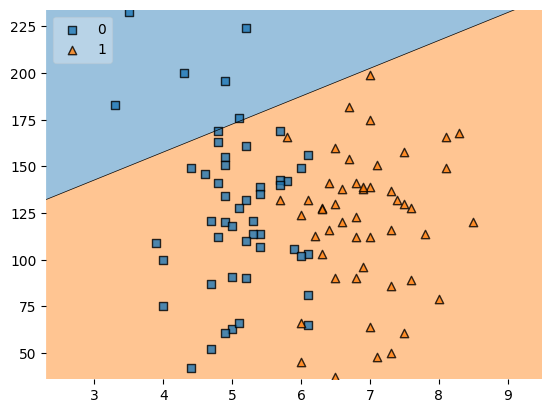

In [ ]:
# plotting decision boundary
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X = X, y = Y.astype('int'), clf = model2, legend = 2)

### Initializing all weights with non-zero constant value